In [1]:
# Install required packages using magic commands
import sys
!{sys.executable} -m pip install pandas>=1.5.0 numpy>=1.21.0 matplotlib>=3.5.0 seaborn>=0.11.0 scikit-learn>=1.1.0 --quiet

# Alternative magic command method
# %pip install pandas numpy matplotlib seaborn scikit-learn --quiet

#Install additional packages for enhanced EDA
!{sys.executable} -m pip install wordcloud plotly textstat --quiet

print("✅ Packages installed successfully!")


✅ Packages installed successfully!


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import MathDatasetLoader
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print('Libraries imported successfully!')


Libraries imported successfully!


In [3]:
loader = MathDatasetLoader()
datasets = loader.get_all_datasets()
for name, df in datasets.items():
    print(f'{name}: {df.shape}')


GSM8K dataset not found locally. Creating sample data...
GSM8K dataset not found locally. Creating sample data...
MathQA dataset not found locally. Creating sample data...
MathQA dataset not found locally. Creating sample data...
MathQA dataset not found locally. Creating sample data...
SVAMP dataset not found locally. Creating sample data...
SVAMP dataset not found locally. Creating sample data...
Custom dataset not found. Creating sample data...
gsm8k_train: (5, 7)
gsm8k_test: (5, 7)
mathqa_train: (5, 7)
mathqa_test: (5, 7)
mathqa_validation: (5, 7)
svamp_train: (5, 7)
svamp_test: (5, 7)
custom: (5, 9)


In [4]:
for name, df in datasets.items():
    print(f'\n{name}')
    display(df.head())
    print(df.describe(include='all'))



gsm8k_train


,question,answer,solution,difficulty,category,dataset,split
0,Janet's dogs eat 2 pounds of dog food per day....,6 pounds,Janet's dogs eat 2 pounds of dog food per day....,basic,word_problem,gsm8k,train
1,There are 15 trees in the grove. Grove workers...,6 trees,"There are 15 trees initially. After planting, ...",basic,word_problem,gsm8k,train
2,Leah had 32 chocolates and her sister had 42. ...,39 chocolates,Leah had 32 chocolates and her sister had 42. ...,intermediate,word_problem,gsm8k,train
3,If there are 3 cars in the parking lot and 2 m...,5 cars,There are 3 cars initially. 2 more cars arrive...,basic,word_problem,gsm8k,train
4,There are 15 trees in the grove. Grove workers...,6 trees,"There are 15 trees initially. After planting, ...",basic,word_problem,gsm8k,train


                                                 question   answer  \
count                                                   5        5   
unique                                                  4        4   
top     There are 15 trees in the grove. Grove workers...  6 trees   
freq                                                    2        2   

                                                 solution difficulty  \
count                                                   5          5   
unique                                                  4          2   
top     There are 15 trees initially. After planting, ...      basic   
freq                                                    2          4   

            category dataset  split  
count              5       5      5  
unique             1       1      1  
top     word_problem   gsm8k  train  
freq               5       5      5  

gsm8k_test


,question,answer,solution,difficulty,category,dataset,split
0,Janet's dogs eat 2 pounds of dog food per day....,6 pounds,Janet's dogs eat 2 pounds of dog food per day....,basic,word_problem,gsm8k,test
1,There are 15 trees in the grove. Grove workers...,6 trees,"There are 15 trees initially. After planting, ...",basic,word_problem,gsm8k,test
2,Leah had 32 chocolates and her sister had 42. ...,39 chocolates,Leah had 32 chocolates and her sister had 42. ...,intermediate,word_problem,gsm8k,test
3,If there are 3 cars in the parking lot and 2 m...,5 cars,There are 3 cars initially. 2 more cars arrive...,basic,word_problem,gsm8k,test
4,There are 15 trees in the grove. Grove workers...,6 trees,"There are 15 trees initially. After planting, ...",basic,word_problem,gsm8k,test


                                                 question   answer  \
count                                                   5        5   
unique                                                  4        4   
top     There are 15 trees in the grove. Grove workers...  6 trees   
freq                                                    2        2   

                                                 solution difficulty  \
count                                                   5          5   
unique                                                  4          2   
top     There are 15 trees initially. After planting, ...      basic   
freq                                                    2          4   

            category dataset split  
count              5       5     5  
unique             1       1     1  
top     word_problem   gsm8k  test  
freq               5       5     5  

mathqa_train


...

                                                sQuestion lSolutions  \
count                                                   5          5   
unique                                                  5          5   
top     A train travels 120 miles in 2 hours. What is ...       [60]   
freq                                                    1          1   
mean                                                  NaN        NaN   
std                                                   NaN        NaN   
min                                                   NaN        NaN   
25%                                                   NaN        NaN   
50%                                                   NaN        NaN   
75%                                                   NaN        NaN   
max                                                   NaN        NaN   

       lEquations    iIndex     category dataset  split  
count           5  5.000000            5       5      5  
unique          5  

,sQuestion,lSolutions,lEquations,iIndex,category,dataset,split
0,A train travels 120 miles in 2 hours. What is ...,[60],[120/2],1,speed,svamp,test
1,John has 5 apples. He gives 2 to Mary. How man...,[3],[5-2],2,subtraction,svamp,test
2,A rectangle has length 8 and width 6. What is ...,[48],[8*6],3,area,svamp,test
3,If a car travels 60 miles per hour for 3 hours...,[180],[60*3],4,distance,svamp,test
4,There are 20 students in a class. 12 are girls...,[8],[20-12],5,subtraction,svamp,test


                                                sQuestion lSolutions  \
count                                                   5          5   
unique                                                  5          5   
top     A train travels 120 miles in 2 hours. What is ...       [60]   
freq                                                    1          1   
mean                                                  NaN        NaN   
std                                                   NaN        NaN   
min                                                   NaN        NaN   
25%                                                   NaN        NaN   
50%                                                   NaN        NaN   
75%                                                   NaN        NaN   
max                                                   NaN        NaN   

       lEquations    iIndex     category dataset split  
count           5  5.000000            5       5     5  
unique          5    

,problem_id,problem_text,difficulty_level,subject,solution_steps,final_answer,symbolic_complexity,step_count,dataset
0,P001,Solve for x: 2x + 5 = 13,basic,algebra,"[Subtract 5 from both sides: 2x = 8, Divide by...",x = 4,2,2,custom
1,P002,Find the derivative of f(x) = x^2 + 3x + 1,intermediate,calculus,"[Apply power rule: d/dx(x^2) = 2x, Apply const...",f'(x) = 2x + 3,4,3,custom
2,P003,Calculate the area under the curve y = x^2 fro...,advanced,calculus,"[Set up integral: ∫₀² x² dx, Apply power rule:...",Area = 8/3,6,3,custom
3,P004,Prove that the sum of two even numbers is even,intermediate,number_theory,"[Let a = 2k, b = 2m for integers k,m, a + b = ...",The sum is even,5,3,custom
4,P005,Find the limit as x approaches 0 of (sin(x))/x,advanced,calculus,"[Use L'Hôpital's rule, d/dx(sin(x)) = cos(x), ...",Limit = 1,7,3,custom


       problem_id              problem_text difficulty_level   subject  \
count           5                         5                5         5   
unique          5                         5                3         3   
top          P001  Solve for x: 2x + 5 = 13     intermediate  calculus   
freq            1                         1                2         3   
mean          NaN                       NaN              NaN       NaN   
std           NaN                       NaN              NaN       NaN   
min           NaN                       NaN              NaN       NaN   
25%           NaN                       NaN              NaN       NaN   
50%           NaN                       NaN              NaN       NaN   
75%           NaN                       NaN              NaN       NaN   
max           NaN                       NaN              NaN       NaN   

                                           solution_steps final_answer  \
count                                

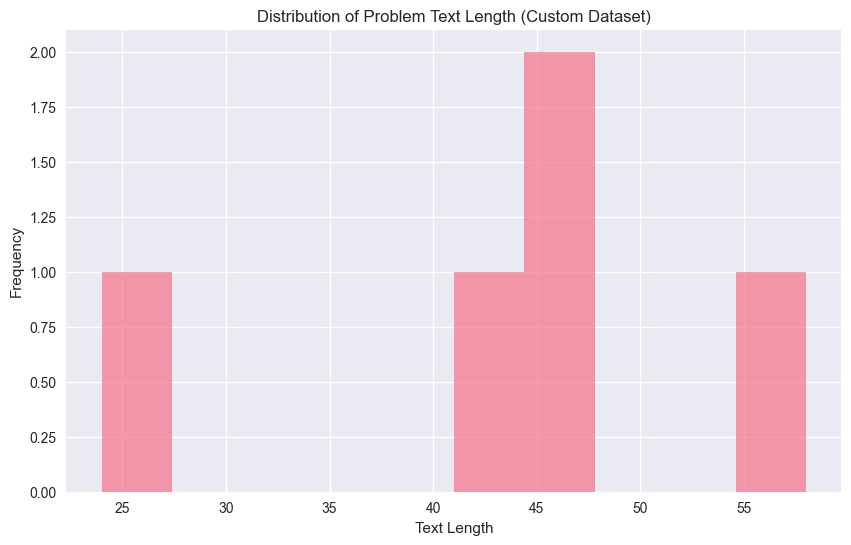

In [5]:
custom_df = datasets['custom']
custom_df['text_length'] = custom_df['problem_text'].str.len()
plt.figure(figsize=(10, 6))
plt.hist(custom_df['text_length'], bins=10, alpha=0.7)
plt.title('Distribution of Problem Text Length (Custom Dataset)')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()


In [6]:
# Enhanced EDA: Comprehensive Analysis of Math Datasets
print("🔍 Starting comprehensive EDA analysis...")

# First, let's update our dataset loading to use the preprocessed data
import re
from collections import Counter
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


🔍 Starting comprehensive EDA analysis...


In [7]:
# Install additional packages for enhanced EDA
import sys
!{sys.executable} -m pip install wordcloud plotly textstat --quiet

print("📦 Additional EDA packages installed!")


📦 Additional EDA packages installed!


In [8]:
## 5. Complete Preprocessing Pipeline

def preprocess_datasets(datasets):
    """
    Complete preprocessing pipeline for all math datasets
    """
    preprocessed = {}
    
    for name, df in datasets.items():
        print(f"🔄 Preprocessing {name}...")
        df_processed = df.copy()
        
        # Standardize problem text column
        if 'question' in df.columns:
            df_processed['problem_text'] = df_processed['question']
        elif 'Problem' in df.columns:
            df_processed['problem_text'] = df_processed['Problem']
        elif 'sQuestion' in df.columns:
            df_processed['problem_text'] = df_processed['sQuestion']
        elif 'question_concat' in df.columns:
            df_processed['problem_text'] = df_processed['question_concat']
        
        # Standardize answer column
        if 'answer' in df.columns:
            df_processed['solution_text'] = df_processed['answer']
        elif 'Rationale' in df.columns:
            df_processed['solution_text'] = df_processed['Rationale']
        elif 'final_answer' in df.columns:
            df_processed['solution_text'] = df_processed['final_answer']
        
        # Extract text features
        if 'problem_text' in df_processed.columns:
            df_processed['text_length'] = df_processed['problem_text'].str.len()
            df_processed['word_count'] = df_processed['problem_text'].str.split().str.len()
            df_processed['sentence_count'] = df_processed['problem_text'].str.count(r'[.!?]') + 1
            
            # Mathematical operators count
            math_ops = ['+', '-', '*', '/', '=', '>', '<', '≥', '≤', '∫', '∑', '√']
            df_processed['math_ops_count'] = df_processed['problem_text'].apply(
                lambda x: sum(str(x).count(op) for op in math_ops) if pd.notna(x) else 0
            )
            
            # Number count in problem
            df_processed['number_count'] = df_processed['problem_text'].apply(
                lambda x: len(re.findall(r'\b\d+\.?\d*\b', str(x))) if pd.notna(x) else 0
            )
        
        # Standardize difficulty if available
        if 'difficulty' in df_processed.columns:
            df_processed['difficulty_level'] = df_processed['difficulty']
        elif 'difficulty_level' not in df_processed.columns:
            # Infer difficulty based on text complexity
            if 'text_length' in df_processed.columns:
                df_processed['difficulty_level'] = pd.cut(
                    df_processed['text_length'], 
                    bins=[0, 50, 150, 500, float('inf')],
                    labels=['basic', 'intermediate', 'advanced', 'expert']
                )
        
        # Add dataset identifier
        df_processed['dataset_name'] = name
        
        preprocessed[name] = df_processed
        
    print("✅ Preprocessing completed!")
    return preprocessed

# Apply preprocessing
preprocessed_datasets = preprocess_datasets(datasets)


🔄 Preprocessing gsm8k_train...
🔄 Preprocessing gsm8k_test...
🔄 Preprocessing mathqa_train...
🔄 Preprocessing mathqa_test...
🔄 Preprocessing mathqa_validation...
🔄 Preprocessing svamp_train...
🔄 Preprocessing svamp_test...
🔄 Preprocessing custom...
✅ Preprocessing completed!


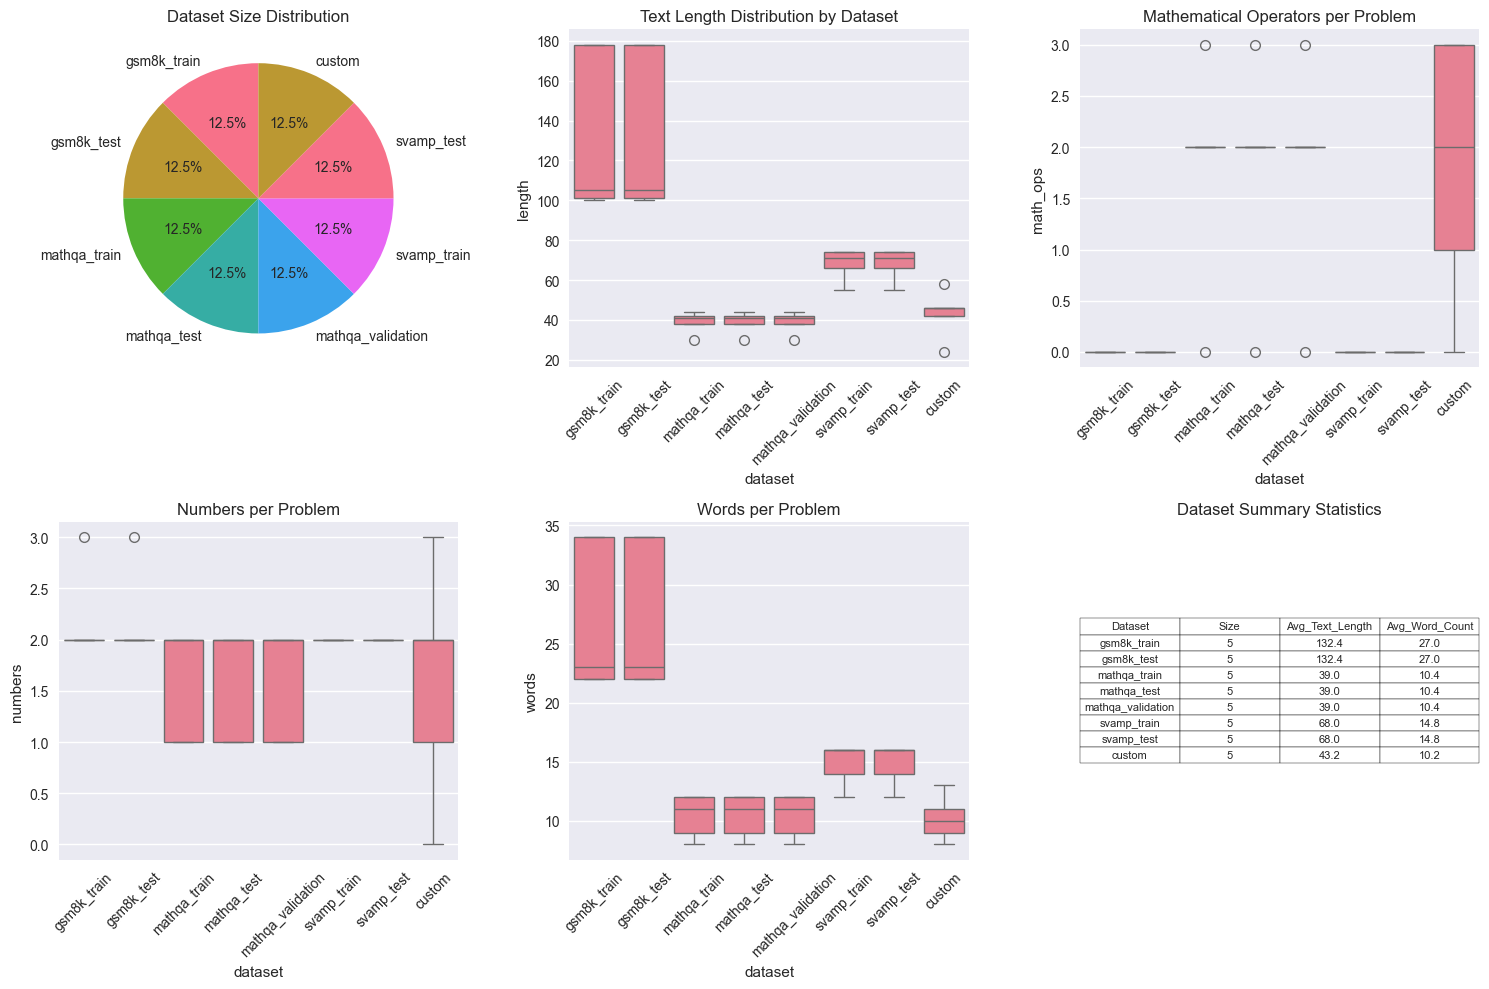

In [9]:
## 6. Dataset Overview and Statistics

def analyze_dataset_overview(preprocessed_datasets):
    """Comprehensive overview of all datasets"""
    
    # Combine all datasets for overall statistics
    combined_data = []
    for name, df in preprocessed_datasets.items():
        temp_df = df.copy()
        temp_df['dataset'] = name
        combined_data.append(temp_df)
    
    # Dataset size comparison
    plt.figure(figsize=(15, 10))
    
    # Dataset sizes
    plt.subplot(2, 3, 1)
    sizes = [len(df) for df in preprocessed_datasets.values()]
    names = list(preprocessed_datasets.keys())
    plt.pie(sizes, labels=names, autopct='%1.1f%%', startangle=90)
    plt.title('Dataset Size Distribution')
    
    # Text length comparison across datasets
    plt.subplot(2, 3, 2)
    text_lengths = []
    dataset_labels = []
    for name, df in preprocessed_datasets.items():
        if 'text_length' in df.columns:
            text_lengths.extend(df['text_length'].dropna().tolist())
            dataset_labels.extend([name] * len(df['text_length'].dropna()))
    
    df_text = pd.DataFrame({'length': text_lengths, 'dataset': dataset_labels})
    sns.boxplot(data=df_text, x='dataset', y='length')
    plt.xticks(rotation=45)
    plt.title('Text Length Distribution by Dataset')
    
    # Mathematical complexity
    plt.subplot(2, 3, 3)
    math_complexity = []
    dataset_labels_math = []
    for name, df in preprocessed_datasets.items():
        if 'math_ops_count' in df.columns:
            math_complexity.extend(df['math_ops_count'].dropna().tolist())
            dataset_labels_math.extend([name] * len(df['math_ops_count'].dropna()))
    
    if math_complexity:
        df_math = pd.DataFrame({'math_ops': math_complexity, 'dataset': dataset_labels_math})
        sns.boxplot(data=df_math, x='dataset', y='math_ops')
        plt.xticks(rotation=45)
        plt.title('Mathematical Operators per Problem')
    
    # Number count distribution
    plt.subplot(2, 3, 4)
    number_counts = []
    dataset_labels_num = []
    for name, df in preprocessed_datasets.items():
        if 'number_count' in df.columns:
            number_counts.extend(df['number_count'].dropna().tolist())
            dataset_labels_num.extend([name] * len(df['number_count'].dropna()))
    
    if number_counts:
        df_num = pd.DataFrame({'numbers': number_counts, 'dataset': dataset_labels_num})
        sns.boxplot(data=df_num, x='dataset', y='numbers')
        plt.xticks(rotation=45)
        plt.title('Numbers per Problem')
    
    # Word count distribution
    plt.subplot(2, 3, 5)
    word_counts = []
    dataset_labels_words = []
    for name, df in preprocessed_datasets.items():
        if 'word_count' in df.columns:
            word_counts.extend(df['word_count'].dropna().tolist())
            dataset_labels_words.extend([name] * len(df['word_count'].dropna()))
    
    if word_counts:
        df_words = pd.DataFrame({'words': word_counts, 'dataset': dataset_labels_words})
        sns.boxplot(data=df_words, x='dataset', y='words')
        plt.xticks(rotation=45)
        plt.title('Words per Problem')
    
    # Dataset summary table
    plt.subplot(2, 3, 6)
    summary_data = []
    for name, df in preprocessed_datasets.items():
        summary_data.append({
            'Dataset': name,
            'Size': len(df),
            'Avg_Text_Length': df['text_length'].mean() if 'text_length' in df.columns else 'N/A',
            'Avg_Word_Count': df['word_count'].mean() if 'word_count' in df.columns else 'N/A'
        })
    
    summary_df = pd.DataFrame(summary_data)
    plt.axis('tight')
    plt.axis('off')
    table = plt.table(cellText=summary_df.round(1).values, 
                     colLabels=summary_df.columns,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    plt.title('Dataset Summary Statistics')
    
    plt.tight_layout()
    plt.show()
    
    return summary_df

summary_stats = analyze_dataset_overview(preprocessed_datasets)


📊 Analyzing difficulty patterns...


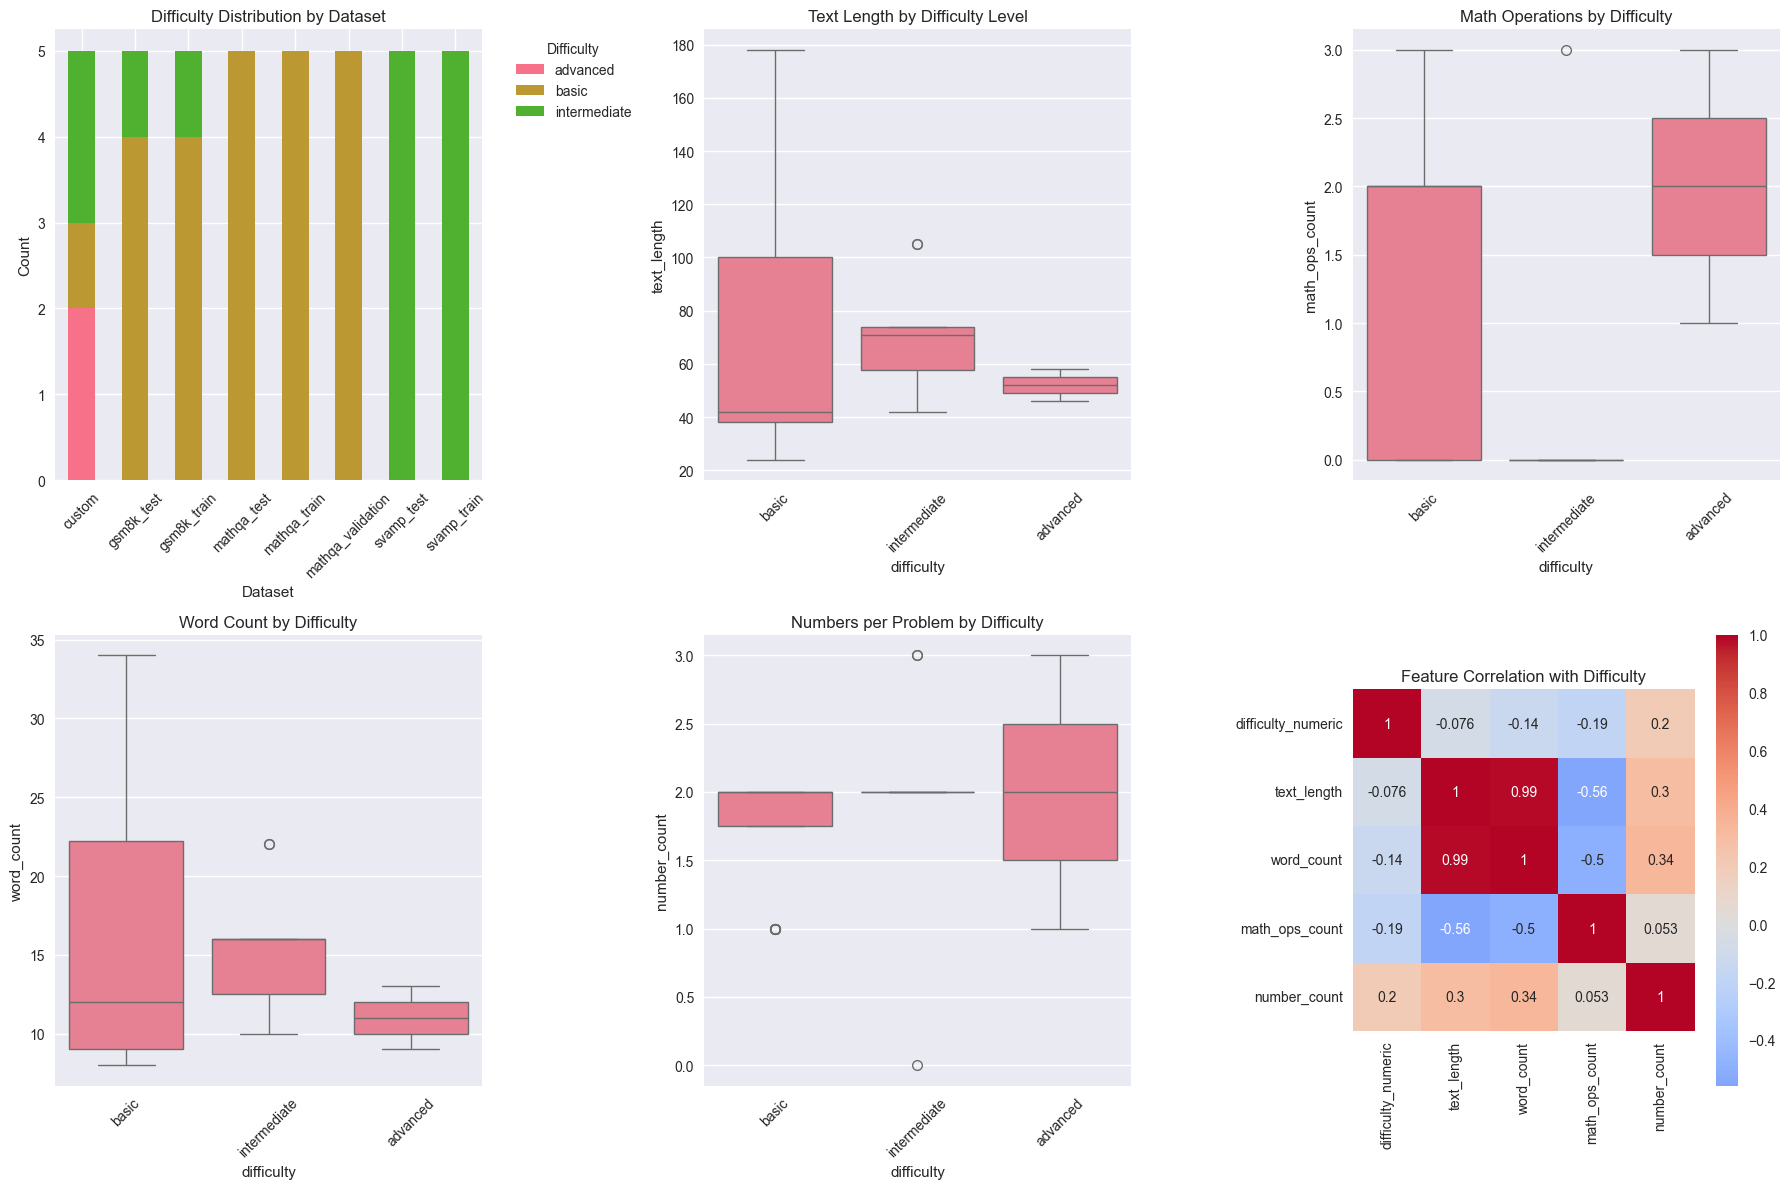


📈 Difficulty Level Statistics:
             text_length        word_count       math_ops_count        \
                    mean    std       mean   std           mean   std   
difficulty                                                              
advanced           52.00   8.49      11.00  2.83           2.00  1.41   
basic              71.79  54.05      16.25  9.41           1.21  1.18   
intermediate       69.86  18.31      15.21  3.56           0.21  0.80   

             number_count        
                     mean   std  
difficulty                       
advanced             2.00  1.41  
basic                1.75  0.44  
intermediate         2.00  0.68  


In [10]:
## 7. Deep Analysis: Problem Difficulty Patterns

def analyze_difficulty_patterns(preprocessed_datasets):
    """Deep analysis of problem difficulty across datasets"""
    
    print("📊 Analyzing difficulty patterns...")
    
    # Collect difficulty data from all datasets
    difficulty_data = []
    for name, df in preprocessed_datasets.items():
        if 'difficulty_level' in df.columns:
            for _, row in df.iterrows():
                difficulty_data.append({
                    'dataset': name,
                    'difficulty': str(row['difficulty_level']),
                    'text_length': row.get('text_length', 0),
                    'word_count': row.get('word_count', 0),
                    'math_ops_count': row.get('math_ops_count', 0),
                    'number_count': row.get('number_count', 0)
                })
    
    if not difficulty_data:
        print("⚠️ No difficulty data found in datasets")
        return
    
    difficulty_df = pd.DataFrame(difficulty_data)
    
    # Create comprehensive difficulty analysis
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Difficulty distribution across datasets
    axes[0, 0].set_title('Difficulty Distribution by Dataset')
    difficulty_counts = difficulty_df.groupby(['dataset', 'difficulty']).size().unstack(fill_value=0)
    difficulty_counts.plot(kind='bar', stacked=True, ax=axes[0, 0])
    axes[0, 0].set_xlabel('Dataset')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend(title='Difficulty', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Text length vs difficulty
    axes[0, 1].set_title('Text Length by Difficulty Level')
    sns.boxplot(data=difficulty_df, x='difficulty', y='text_length', ax=axes[0, 1])
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Mathematical complexity vs difficulty
    axes[0, 2].set_title('Math Operations by Difficulty')
    sns.boxplot(data=difficulty_df, x='difficulty', y='math_ops_count', ax=axes[0, 2])
    axes[0, 2].tick_params(axis='x', rotation=45)
    
    # 4. Word count vs difficulty
    axes[1, 0].set_title('Word Count by Difficulty')
    sns.boxplot(data=difficulty_df, x='difficulty', y='word_count', ax=axes[1, 0])
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 5. Numbers per problem vs difficulty
    axes[1, 1].set_title('Numbers per Problem by Difficulty')
    sns.boxplot(data=difficulty_df, x='difficulty', y='number_count', ax=axes[1, 1])
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    # 6. Correlation heatmap
    axes[1, 2].set_title('Feature Correlation with Difficulty')
    # Create difficulty encoding for correlation
    difficulty_mapping = {'basic': 1, 'intermediate': 2, 'advanced': 3, 'expert': 4}
    difficulty_df['difficulty_numeric'] = difficulty_df['difficulty'].apply(lambda x: difficulty_mapping.get(x, 0))
    
    correlation_features = ['difficulty_numeric', 'text_length', 'word_count', 'math_ops_count', 'number_count']
    correlation_matrix = difficulty_df[correlation_features].corr()
    
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()
    
    # Print difficulty statistics
    print("\n📈 Difficulty Level Statistics:")
    difficulty_stats = difficulty_df.groupby('difficulty').agg({
        'text_length': ['mean', 'std'],
        'word_count': ['mean', 'std'],
        'math_ops_count': ['mean', 'std'],
        'number_count': ['mean', 'std']
    }).round(2)
    
    print(difficulty_stats)
    
    return difficulty_df

difficulty_analysis = analyze_difficulty_patterns(preprocessed_datasets)


🏷️ Analyzing label types and categories...

📋 Analyzing gsm8k_train:
  category: {'word_problem': 5}
  Solution Analysis:
    - Problems with calculations: 0
    - Problems with step-by-step solutions: 0
    - Problems with numerical answers: 5

📋 Analyzing gsm8k_test:
  category: {'word_problem': 5}
  Solution Analysis:
    - Problems with calculations: 0
    - Problems with step-by-step solutions: 0
    - Problems with numerical answers: 5

📋 Analyzing mathqa_train:
  category: {'algebra': 3, 'calculus': 1, 'geometry': 1}
  Solution Analysis:
    - Problems with calculations: 4
    - Problems with step-by-step solutions: 2
    - Problems with numerical answers: 5

📋 Analyzing mathqa_test:
  category: {'algebra': 3, 'calculus': 1, 'geometry': 1}
  Solution Analysis:
    - Problems with calculations: 4
    - Problems with step-by-step solutions: 2
    - Problems with numerical answers: 5

📋 Analyzing mathqa_validation:
  category: {'algebra': 3, 'calculus': 1, 'geometry': 1}
  Solution

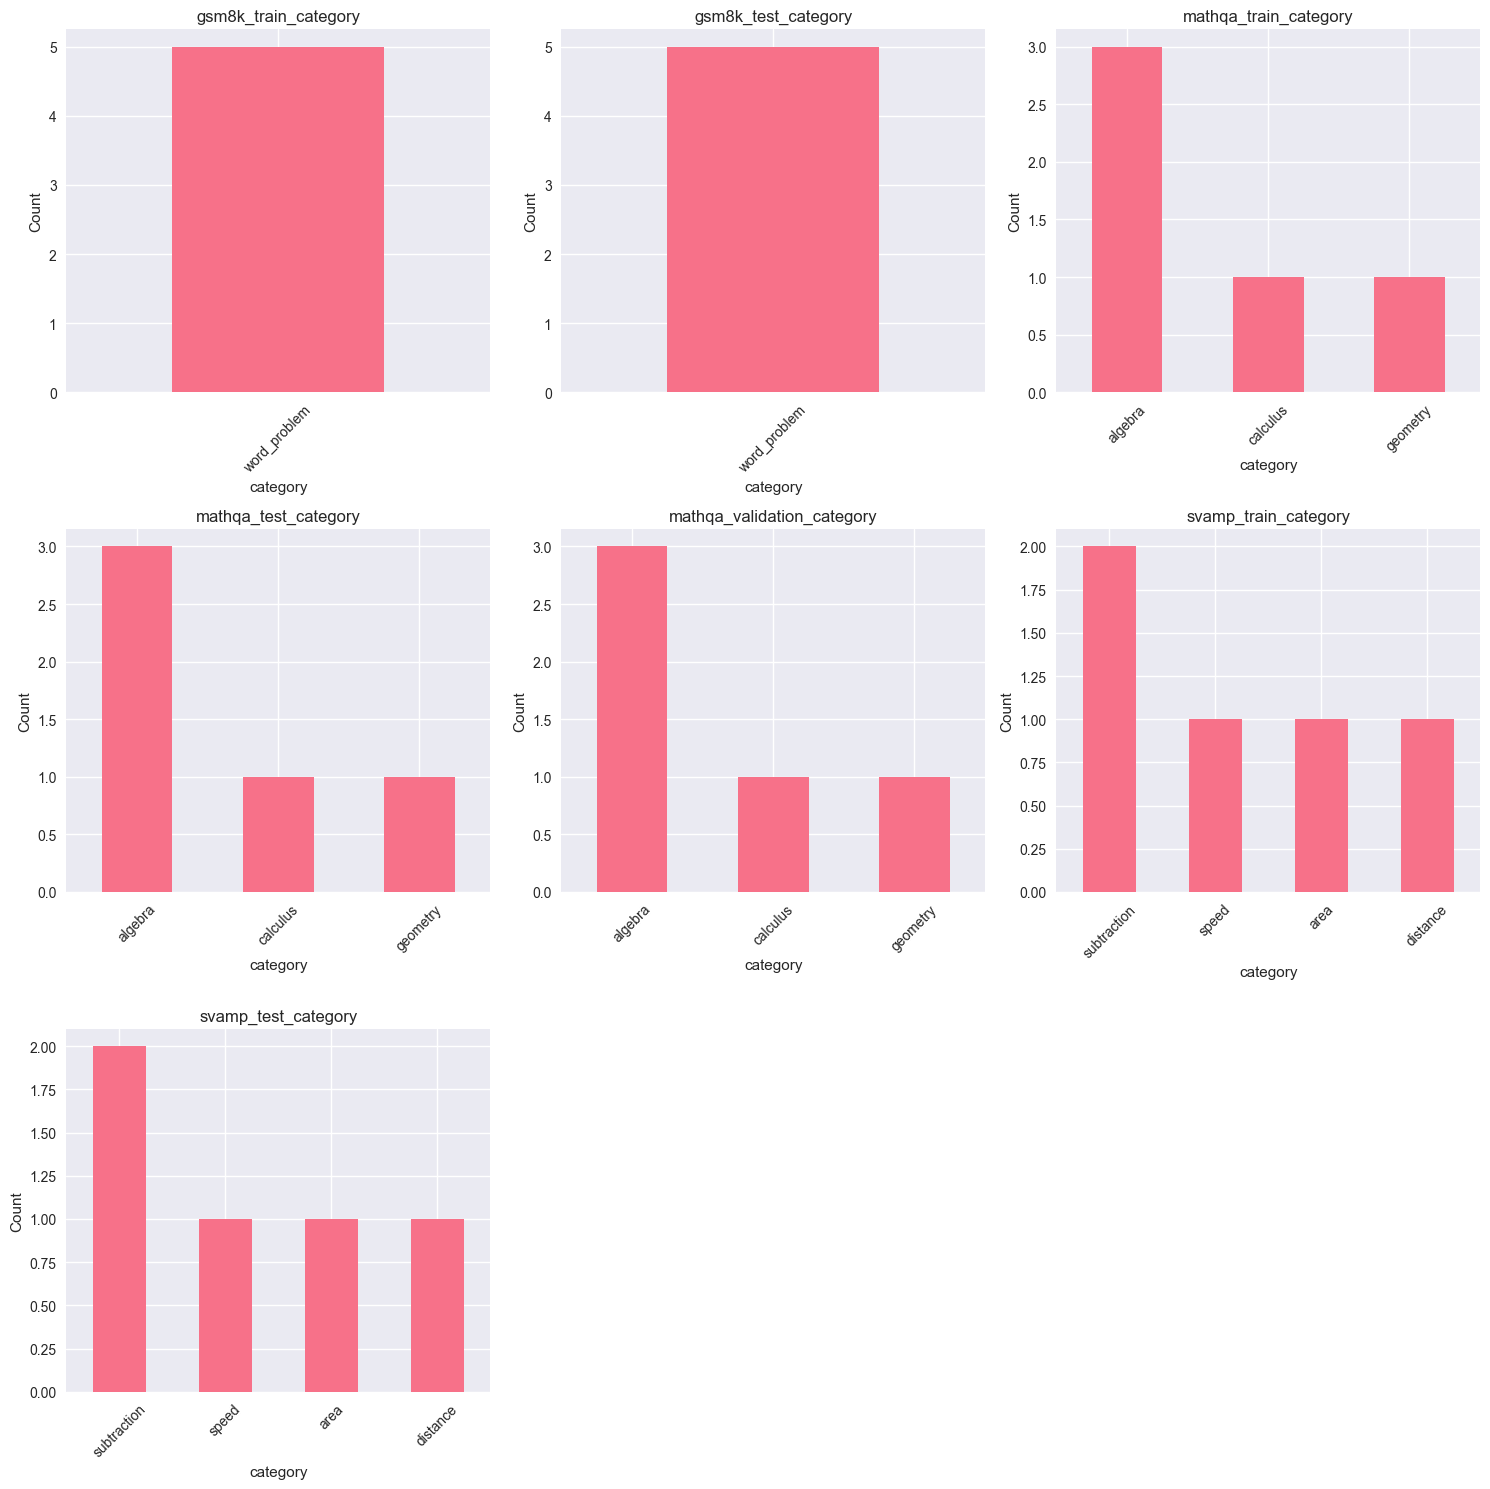

In [11]:
## 8. Label Types and Category Analysis

def analyze_label_categories(preprocessed_datasets):
    """Analyze different types of labels and categories across datasets"""
    
    print("🏷️ Analyzing label types and categories...")
    
    # Collect category information from all datasets
    category_analysis = {}
    
    for name, df in preprocessed_datasets.items():
        print(f"\n📋 Analyzing {name}:")
        
        # Look for category columns
        category_columns = [col for col in df.columns if 'category' in col.lower() or 'type' in col.lower()]
        
        for col in category_columns:
            if col in df.columns:
                print(f"  {col}: {df[col].value_counts().to_dict()}")
                category_analysis[f"{name}_{col}"] = df[col].value_counts()
        
        # Analyze answer types for mathematical problems
        if 'solution_text' in df.columns:
            # Analyze solution characteristics
            solutions = df['solution_text'].dropna().astype(str)
            
            # Check for different solution patterns
            has_calculation = solutions.str.contains(r'[+\-*/=]', regex=True).sum()
            has_steps = solutions.str.contains(r'step|then|next|first', case=False, regex=True).sum()
            has_numbers = solutions.str.contains(r'\d+', regex=True).sum()
            
            print(f"  Solution Analysis:")
            print(f"    - Problems with calculations: {has_calculation}")
            print(f"    - Problems with step-by-step solutions: {has_steps}")
            print(f"    - Problems with numerical answers: {has_numbers}")
    
    # Visualize category distributions
    if category_analysis:
        n_categories = len(category_analysis)
        n_cols = min(3, n_categories)
        n_rows = (n_categories + n_cols - 1) // n_cols
        
        plt.figure(figsize=(15, 5 * n_rows))
        
        for i, (category_name, counts) in enumerate(category_analysis.items(), 1):
            plt.subplot(n_rows, n_cols, i)
            counts.plot(kind='bar')
            plt.title(f'{category_name}')
            plt.xticks(rotation=45)
            plt.ylabel('Count')
        
        plt.tight_layout()
        plt.show()
    
    return category_analysis

category_analysis = analyze_label_categories(preprocessed_datasets)


🔢 Analyzing mathematical operation patterns...

📊 gsm8k_train - Mathematical Operations:
  Addition: 1 problems
  Multiplication: 1 problems
  Division: 1 problems
  Algebra: 5 problems

📊 gsm8k_test - Mathematical Operations:
  Addition: 1 problems
  Multiplication: 1 problems
  Division: 1 problems
  Algebra: 5 problems

📊 mathqa_train - Mathematical Operations:
  Multiplication: 4 problems
  Geometry: 1 problems
  Algebra: 4 problems

📊 mathqa_test - Mathematical Operations:
  Multiplication: 4 problems
  Geometry: 1 problems
  Algebra: 4 problems

📊 mathqa_validation - Mathematical Operations:
  Multiplication: 4 problems
  Geometry: 1 problems
  Algebra: 4 problems

📊 svamp_train - Mathematical Operations:
  Division: 2 problems
  Algebra: 2 problems

📊 svamp_test - Mathematical Operations:
  Division: 2 problems
  Algebra: 2 problems

📊 custom - Mathematical Operations:
  Addition: 1 problems
  Multiplication: 3 problems
  Geometry: 1 problems
  Algebra: 4 problems


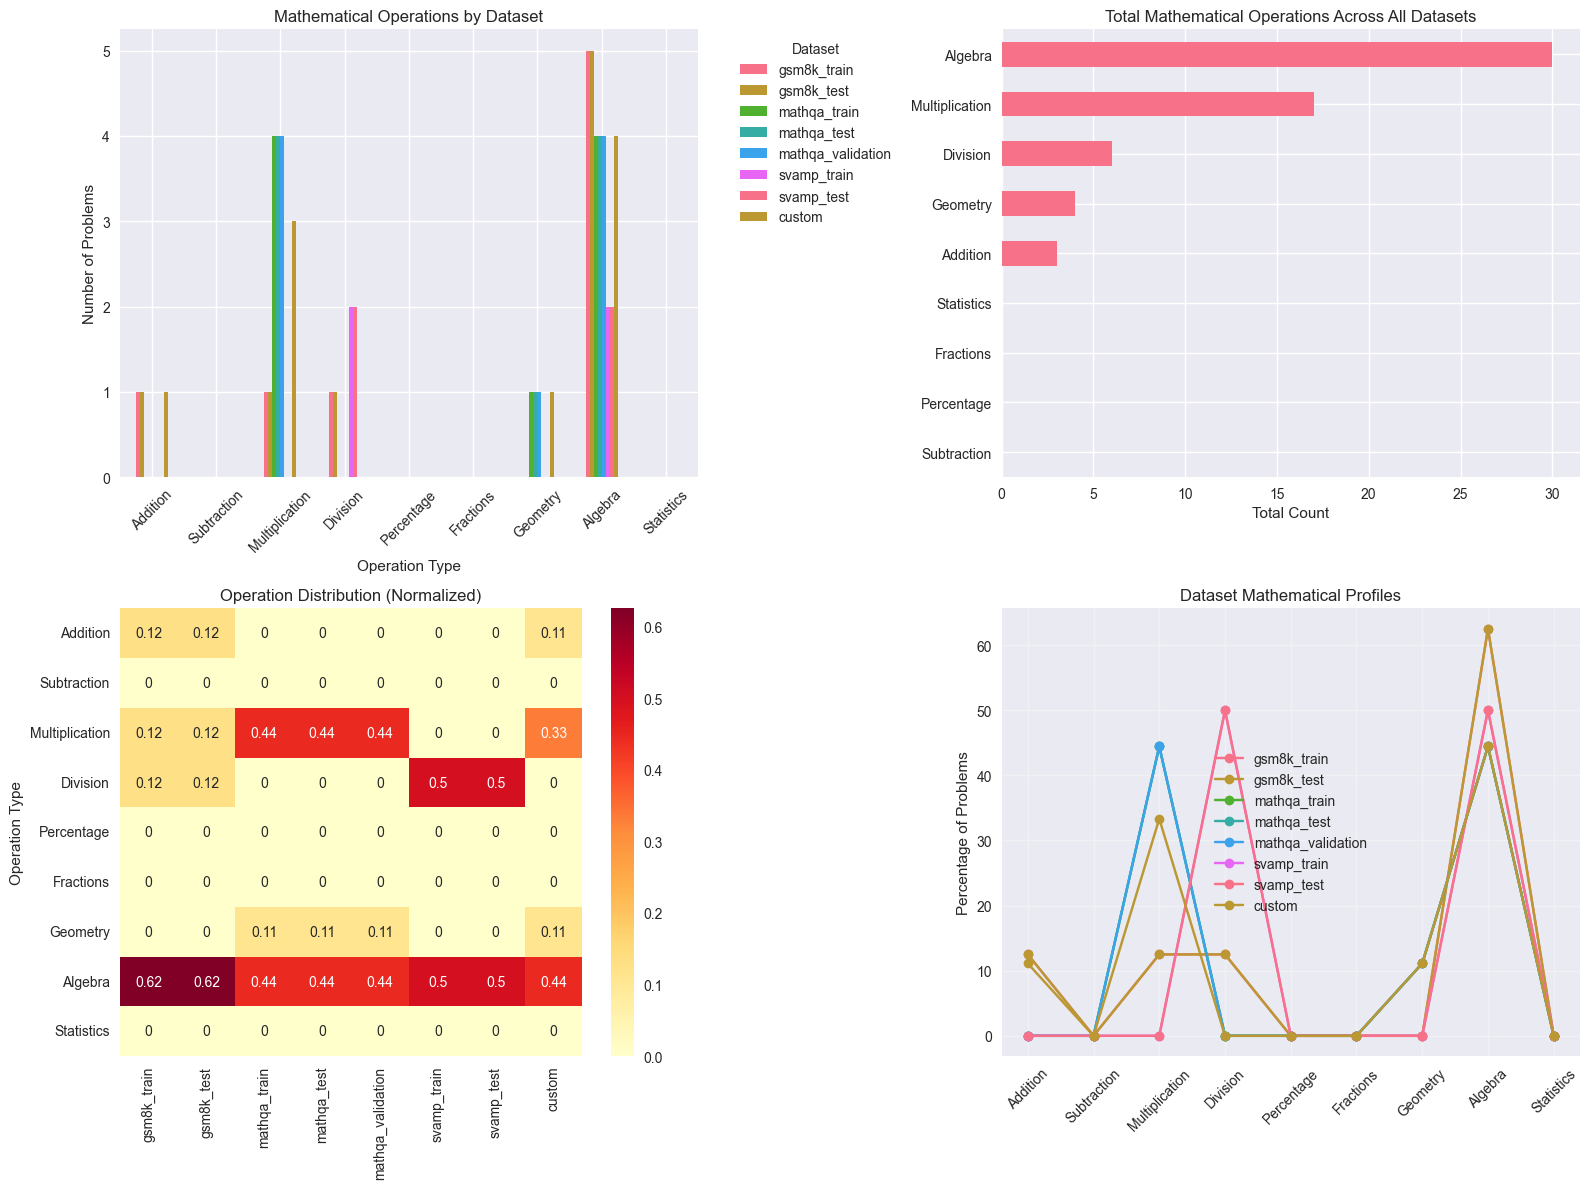

In [12]:
## 9. Mathematical Operation Patterns

def analyze_math_operations(preprocessed_datasets):
    """Deep analysis of mathematical operations and patterns in problems"""
    
    print("🔢 Analyzing mathematical operation patterns...")
    
    # Define mathematical operation patterns
    operation_patterns = {
        'Addition': r'[+\s]plus\s|\sadd\s|\ssum\s|together|\stotal',
        'Subtraction': r'[-\s]minus\s|\ssubtract\s|\sdifference\s|\sless\s|\sremaining',
        'Multiplication': r'[*×]\s|\smultiply\s|\stimes\s|\sof\s|\seach',
        'Division': r'[/÷]\s|\sdivide\s|\ssplit\s|\sper\s|\sshare',
        'Percentage': r'%\s|\spercent\s|\spercentage',
        'Fractions': r'\d+/\d+|\sfraction|\shalf|\sthird|\squarter',
        'Geometry': r'area\s|\sperimeter\s|\svolume\s|\sradius\s|\sdiameter',
        'Algebra': r'[xy]\s|\sequation\s|\ssolve\s|\svariable',
        'Statistics': r'average\s|\smean\s|\smedian\s|\smode\s|\sprobability'
    }
    
    # Analyze operation patterns across datasets
    operation_results = {}
    
    for name, df in preprocessed_datasets.items():
        if 'problem_text' in df.columns:
            problems = df['problem_text'].fillna('').astype(str).str.lower()
            
            operation_counts = {}
            for op_name, pattern in operation_patterns.items():
                count = problems.str.contains(pattern, regex=True, case=False).sum()
                operation_counts[op_name] = count
            
            operation_results[name] = operation_counts
            print(f"\n📊 {name} - Mathematical Operations:")
            for op, count in operation_counts.items():
                if count > 0:
                    print(f"  {op}: {count} problems")
    
    # Visualize operation patterns
    if operation_results:
        # Create a comprehensive visualization
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Operation distribution by dataset
        op_df = pd.DataFrame(operation_results).fillna(0)
        op_df.plot(kind='bar', ax=axes[0, 0])
        axes[0, 0].set_title('Mathematical Operations by Dataset')
        axes[0, 0].set_xlabel('Operation Type')
        axes[0, 0].set_ylabel('Number of Problems')
        axes[0, 0].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Total operations across all datasets
        total_ops = op_df.sum(axis=1).sort_values(ascending=True)
        total_ops.plot(kind='barh', ax=axes[0, 1])
        axes[0, 1].set_title('Total Mathematical Operations Across All Datasets')
        axes[0, 1].set_xlabel('Total Count')
        
        # 3. Operation complexity heatmap
        op_df_norm = op_df.div(op_df.sum(axis=0), axis=1).fillna(0)
        sns.heatmap(op_df_norm, annot=True, cmap='YlOrRd', ax=axes[1, 0])
        axes[1, 0].set_title('Operation Distribution (Normalized)')
        axes[1, 0].set_ylabel('Operation Type')
        
        # 4. Dataset operation profiles
        axes[1, 1].set_title('Dataset Mathematical Profiles')
        for dataset in op_df.columns:
            if op_df[dataset].sum() > 0:  # Only plot datasets with operations
                values = op_df[dataset] / op_df[dataset].sum() * 100  # Convert to percentages
                axes[1, 1].plot(values.values, label=dataset, marker='o')
        
        axes[1, 1].set_xticks(range(len(op_df.index)))
        axes[1, 1].set_xticklabels(op_df.index, rotation=45)
        axes[1, 1].set_ylabel('Percentage of Problems')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return operation_results

math_operations = analyze_math_operations(preprocessed_datasets)


📚 Analyzing text complexity and readability...

📊 gsm8k_train - Text Complexity Metrics:
  Average word length: 3.87
  Unique words ratio: 0.76
  Punctuation density: 0.0249

📊 gsm8k_test - Text Complexity Metrics:
  Average word length: 3.87
  Unique words ratio: 0.76
  Punctuation density: 0.0249

📊 mathqa_train - Text Complexity Metrics:
  Average word length: 2.91
  Unique words ratio: 0.97
  Punctuation density: 0.0168

📊 mathqa_test - Text Complexity Metrics:
  Average word length: 2.91
  Unique words ratio: 0.97
  Punctuation density: 0.0168

📊 mathqa_validation - Text Complexity Metrics:
  Average word length: 2.91
  Unique words ratio: 0.97
  Punctuation density: 0.0168

📊 svamp_train - Text Complexity Metrics:
  Average word length: 3.67
  Unique words ratio: 0.93
  Punctuation density: 0.0355

📊 svamp_test - Text Complexity Metrics:
  Average word length: 3.67
  Unique words ratio: 0.93
  Punctuation density: 0.0355

📊 custom - Text Complexity Metrics:
  Average word length:

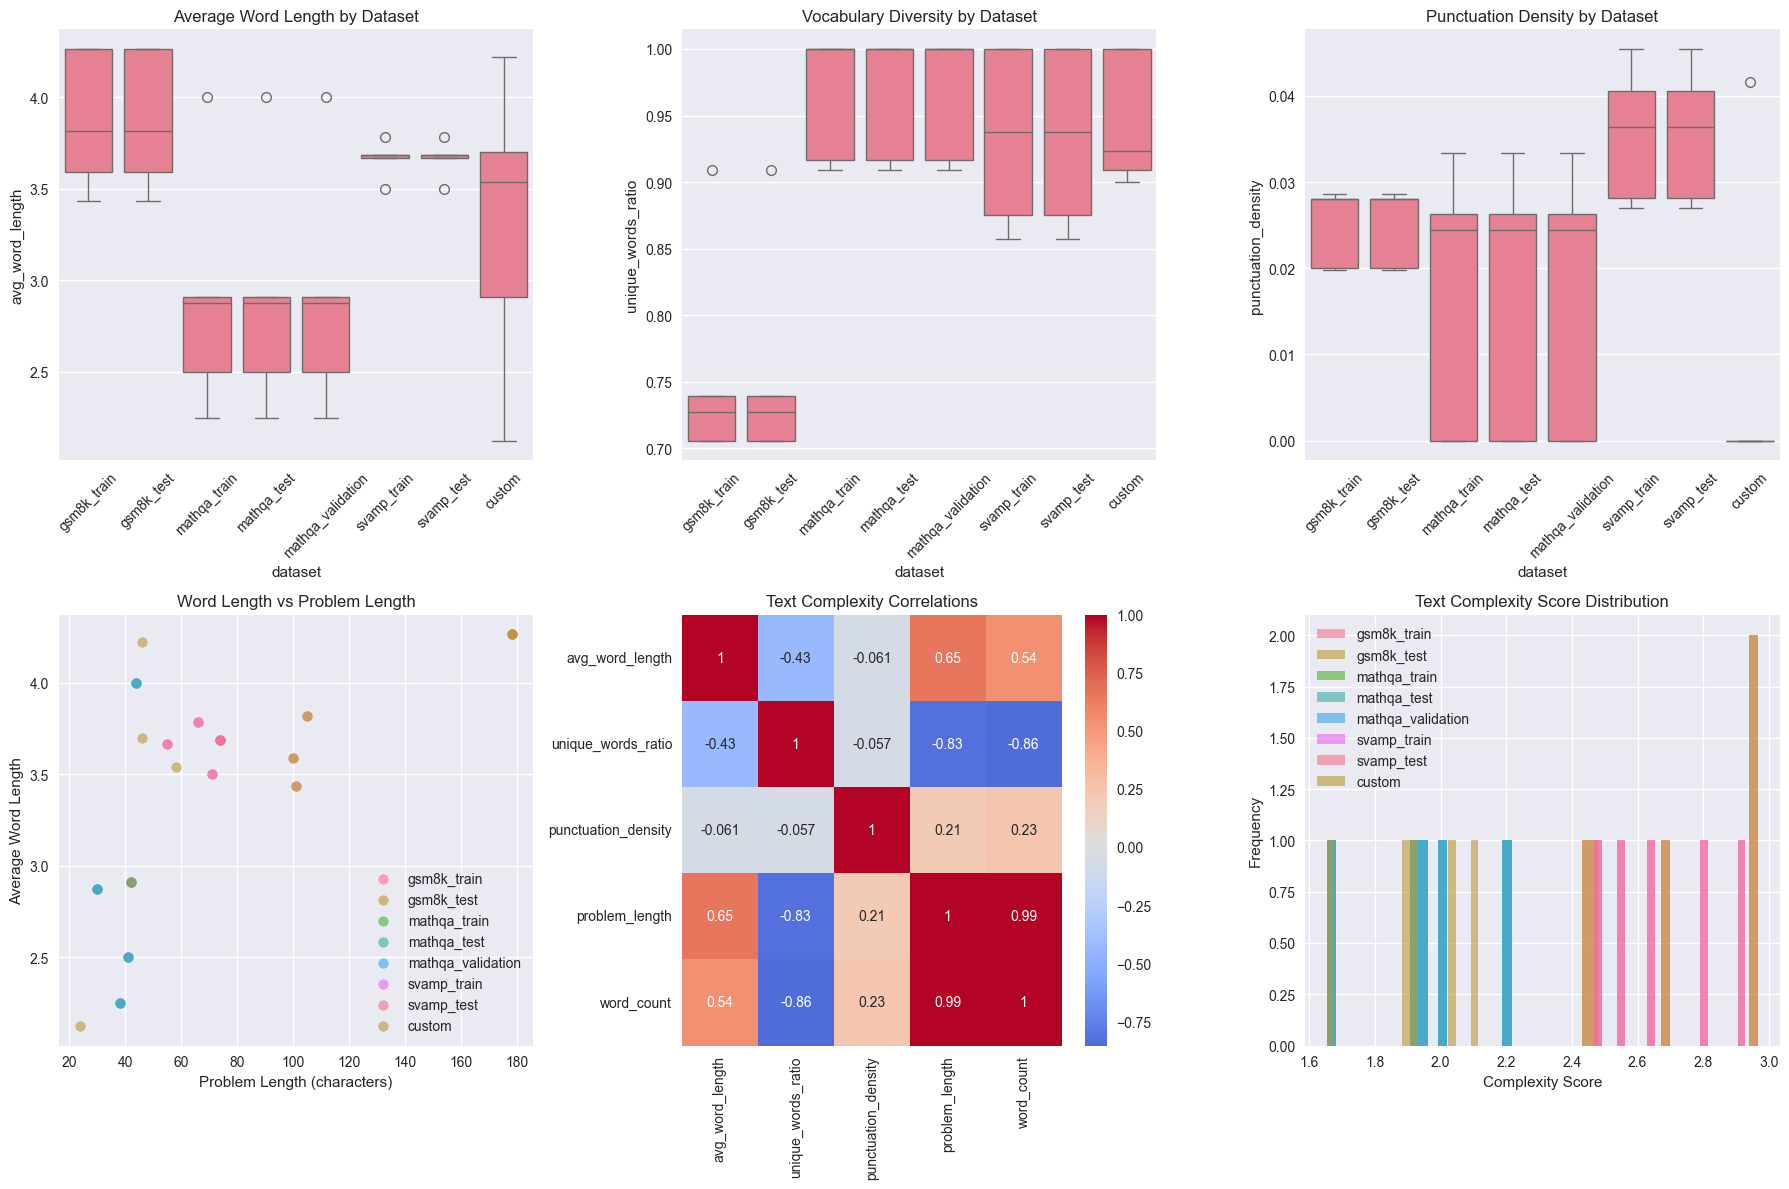

In [13]:
## 10. Text Complexity and Readability Analysis

def analyze_text_complexity(preprocessed_datasets):
    """Analyze text complexity and readability of math problems"""
    
    print("📚 Analyzing text complexity and readability...")
    
    complexity_results = {}
    
    for name, df in preprocessed_datasets.items():
        if 'problem_text' in df.columns:
            problems = df['problem_text'].fillna('').astype(str)
            
            # Calculate various complexity metrics
            complexity_metrics = {
                'avg_word_length': problems.apply(lambda x: np.mean([len(word) for word in x.split()]) if x.split() else 0),
                'unique_words_ratio': problems.apply(lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0),
                'punctuation_density': problems.apply(lambda x: sum(1 for c in x if c in '.,!?;:') / len(x) if x else 0),
                'capital_letter_ratio': problems.apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if x else 0)
            }
            
            complexity_df = pd.DataFrame(complexity_metrics)
            complexity_df['dataset'] = name
            complexity_df['problem_length'] = df.get('text_length', 0)
            complexity_df['word_count'] = df.get('word_count', 0)
            
            complexity_results[name] = complexity_df
            
            print(f"\n📊 {name} - Text Complexity Metrics:")
            print(f"  Average word length: {complexity_df['avg_word_length'].mean():.2f}")
            print(f"  Unique words ratio: {complexity_df['unique_words_ratio'].mean():.2f}")
            print(f"  Punctuation density: {complexity_df['punctuation_density'].mean():.4f}")
    
    # Combine all complexity data
    if complexity_results:
        all_complexity = pd.concat(complexity_results.values(), ignore_index=True)
        
        # Create complexity analysis visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Average word length by dataset
        axes[0, 0].set_title('Average Word Length by Dataset')
        sns.boxplot(data=all_complexity, x='dataset', y='avg_word_length', ax=axes[0, 0])
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Unique words ratio
        axes[0, 1].set_title('Vocabulary Diversity by Dataset')
        sns.boxplot(data=all_complexity, x='dataset', y='unique_words_ratio', ax=axes[0, 1])
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # 3. Punctuation density
        axes[0, 2].set_title('Punctuation Density by Dataset')
        sns.boxplot(data=all_complexity, x='dataset', y='punctuation_density', ax=axes[0, 2])
        axes[0, 2].tick_params(axis='x', rotation=45)
        
        # 4. Word length vs problem length correlation
        axes[1, 0].set_title('Word Length vs Problem Length')
        for dataset in all_complexity['dataset'].unique():
            subset = all_complexity[all_complexity['dataset'] == dataset]
            axes[1, 0].scatter(subset['problem_length'], subset['avg_word_length'], 
                             label=dataset, alpha=0.6)
        axes[1, 0].set_xlabel('Problem Length (characters)')
        axes[1, 0].set_ylabel('Average Word Length')
        axes[1, 0].legend()
        
        # 5. Complexity correlation matrix
        numeric_cols = ['avg_word_length', 'unique_words_ratio', 'punctuation_density', 
                       'problem_length', 'word_count']
        correlation_matrix = all_complexity[numeric_cols].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
        axes[1, 1].set_title('Text Complexity Correlations')
        
        # 6. Complexity distribution
        axes[1, 2].set_title('Text Complexity Score Distribution')
        # Create a composite complexity score
        all_complexity['complexity_score'] = (
            all_complexity['avg_word_length'] * 0.3 +
            (1 - all_complexity['unique_words_ratio']) * 0.3 +
            all_complexity['punctuation_density'] * 100 * 0.2 +
            np.log1p(all_complexity['problem_length']) * 0.2
        )
        
        for dataset in all_complexity['dataset'].unique():
            subset = all_complexity[all_complexity['dataset'] == dataset]
            axes[1, 2].hist(subset['complexity_score'], alpha=0.6, label=dataset, bins=20)
        axes[1, 2].set_xlabel('Complexity Score')
        axes[1, 2].set_ylabel('Frequency')
        axes[1, 2].legend()
        
        plt.tight_layout()
        plt.show()
    
    return complexity_results

complexity_analysis = analyze_text_complexity(preprocessed_datasets)


🔍 Generating Key Insights and Recommendations
📊 DATASET OVERVIEW:
  • Total samples across all datasets: 40
  • Largest dataset: gsm8k_train (5 samples)
  • Number of datasets: 8
\n📚 TEXT COMPLEXITY:
  • Average problem length: 70 characters
  • Text length range: 24-178 characters
\n🔢 MATHEMATICAL OPERATIONS:
  • Most common operation type: Algebra
  • Total operation instances: 60
\n⚡ DIFFICULTY ANALYSIS:
  • Most common difficulty: basic
  • Difficulty distribution: {'basic': 24, 'intermediate': 14, 'advanced': 2}
\n🎯 RECOMMENDATIONS FOR MODEL DEVELOPMENT:
  • Focus on gsm8k_train for primary training due to size
  • Implement difficulty-aware training strategies
  • Consider text length normalization for consistent processing
  • Design operation-specific attention mechanisms
  • Use cross-dataset validation to ensure generalization
\n🔧 DATA PREPROCESSING RECOMMENDATIONS:
  • Standardize problem text formatting across datasets
  • Implement consistent difficulty labeling
  • Create

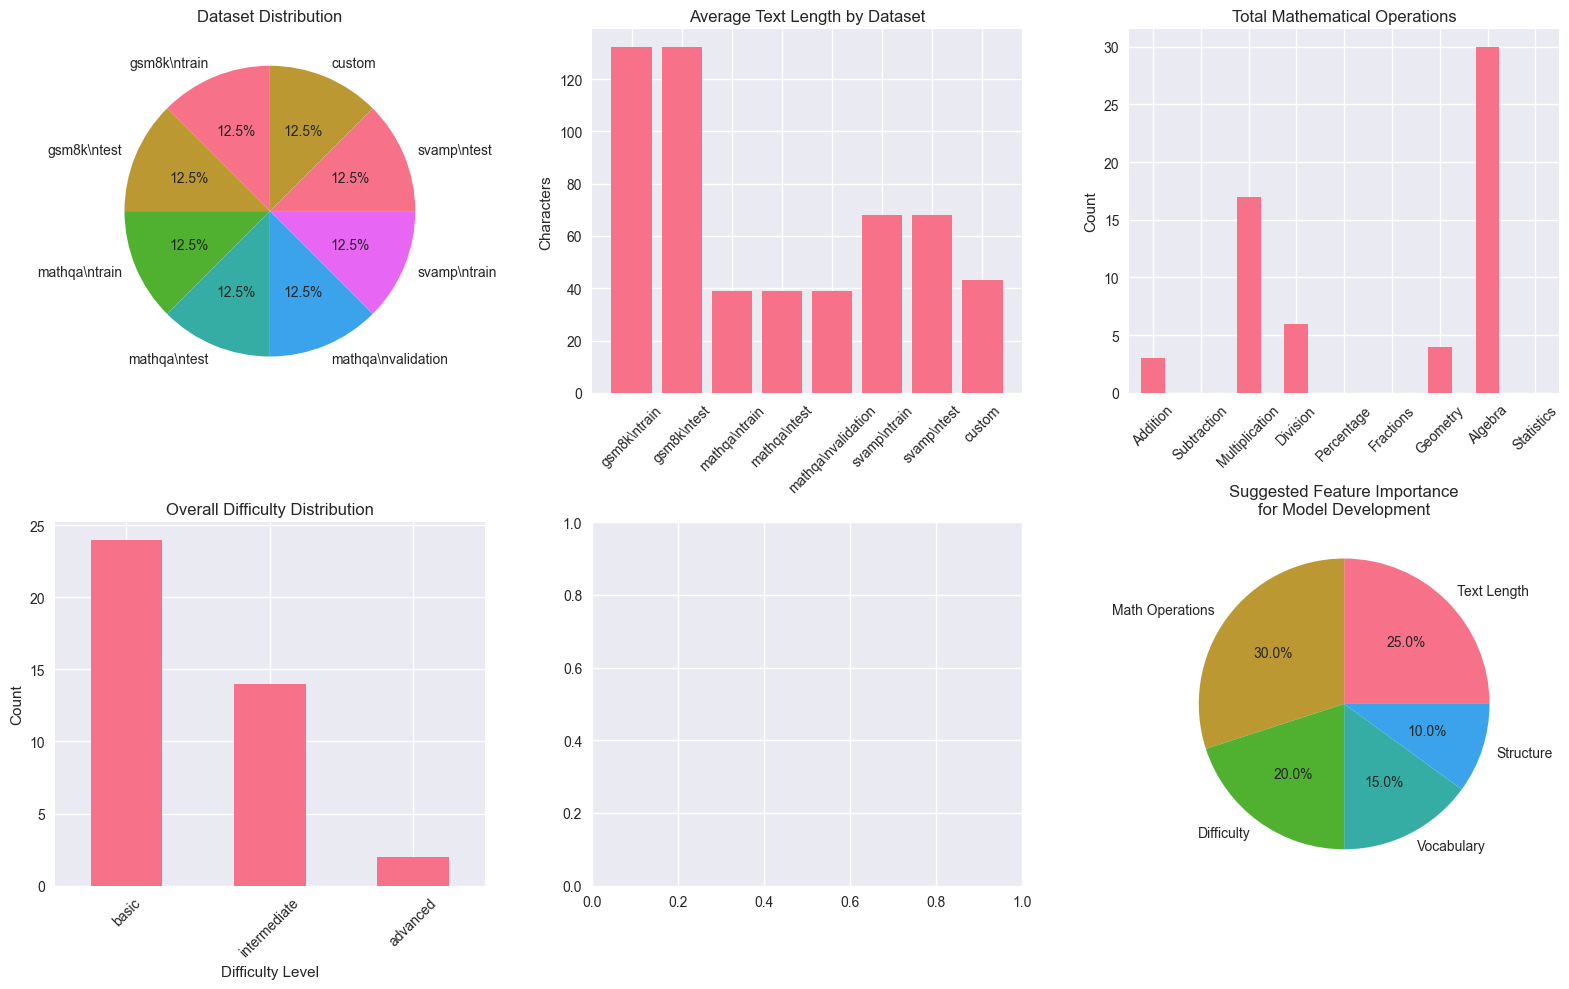

In [14]:
## 11. Key Insights and Recommendations

def generate_insights(preprocessed_datasets, summary_stats, difficulty_analysis, 
                     category_analysis, math_operations, complexity_analysis):
    """Generate key insights and recommendations for model development"""
    
    print("🔍 Generating Key Insights and Recommendations")
    print("=" * 60)
    
    insights = []
    
    # Dataset size insights
    total_samples = sum(len(df) for df in preprocessed_datasets.values())
    largest_dataset = max(preprocessed_datasets.items(), key=lambda x: len(x[1]))
    
    insights.append(f"📊 DATASET OVERVIEW:")
    insights.append(f"  • Total samples across all datasets: {total_samples:,}")
    insights.append(f"  • Largest dataset: {largest_dataset[0]} ({len(largest_dataset[1]):,} samples)")
    insights.append(f"  • Number of datasets: {len(preprocessed_datasets)}")
    
    # Text complexity insights
    if complexity_analysis:
        all_text_lengths = []
        for df in preprocessed_datasets.values():
            if 'text_length' in df.columns:
                all_text_lengths.extend(df['text_length'].dropna().tolist())
        
        if all_text_lengths:
            avg_length = np.mean(all_text_lengths)
            insights.append(f"\\n📚 TEXT COMPLEXITY:")
            insights.append(f"  • Average problem length: {avg_length:.0f} characters")
            insights.append(f"  • Text length range: {min(all_text_lengths)}-{max(all_text_lengths)} characters")
    
    # Mathematical operation insights
    if math_operations:
        total_ops = pd.DataFrame(math_operations).fillna(0).sum(axis=1)
        top_operation = total_ops.idxmax()
        insights.append(f"\\n🔢 MATHEMATICAL OPERATIONS:")
        insights.append(f"  • Most common operation type: {top_operation}")
        insights.append(f"  • Total operation instances: {total_ops.sum()}")
    
    # Difficulty distribution insights
    if difficulty_analysis is not None and not difficulty_analysis.empty:
        difficulty_dist = difficulty_analysis['difficulty'].value_counts()
        most_common_difficulty = difficulty_dist.index[0]
        insights.append(f"\\n⚡ DIFFICULTY ANALYSIS:")
        insights.append(f"  • Most common difficulty: {most_common_difficulty}")
        insights.append(f"  • Difficulty distribution: {dict(difficulty_dist)}")
    
    # Recommendations for model development
    insights.append(f"\\n🎯 RECOMMENDATIONS FOR MODEL DEVELOPMENT:")
    insights.append(f"  • Focus on {largest_dataset[0]} for primary training due to size")
    insights.append(f"  • Implement difficulty-aware training strategies")
    insights.append(f"  • Consider text length normalization for consistent processing")
    insights.append(f"  • Design operation-specific attention mechanisms")
    insights.append(f"  • Use cross-dataset validation to ensure generalization")
    
    # Data quality recommendations
    insights.append(f"\\n🔧 DATA PREPROCESSING RECOMMENDATIONS:")
    insights.append(f"  • Standardize problem text formatting across datasets")
    insights.append(f"  • Implement consistent difficulty labeling")
    insights.append(f"  • Create balanced training splits by difficulty")
    insights.append(f"  • Consider augmentation for underrepresented categories")
    
    # Print all insights
    for insight in insights:
        print(insight)
    
    # Create a summary visualization
    plt.figure(figsize=(16, 10))
    
    # Dataset sizes
    plt.subplot(2, 3, 1)
    sizes = [len(df) for df in preprocessed_datasets.values()]
    names = [name.replace('_', '\\n') for name in preprocessed_datasets.keys()]
    plt.pie(sizes, labels=names, autopct='%1.1f%%', startangle=90)
    plt.title('Dataset Distribution')
    
    # Average text lengths
    plt.subplot(2, 3, 2)
    avg_lengths = []
    dataset_names = []
    for name, df in preprocessed_datasets.items():
        if 'text_length' in df.columns:
            avg_lengths.append(df['text_length'].mean())
            dataset_names.append(name)
    
    if avg_lengths:
        plt.bar(range(len(avg_lengths)), avg_lengths)
        plt.xticks(range(len(dataset_names)), [name.replace('_', '\\n') for name in dataset_names], rotation=45)
        plt.title('Average Text Length by Dataset')
        plt.ylabel('Characters')
    
    # Mathematical operations summary
    plt.subplot(2, 3, 3)
    if math_operations:
        total_ops = pd.DataFrame(math_operations).fillna(0).sum(axis=1)
        total_ops.plot(kind='bar')
        plt.title('Total Mathematical Operations')
        plt.xticks(rotation=45)
        plt.ylabel('Count')
    
    # Difficulty distribution (if available)
    plt.subplot(2, 3, 4)
    if difficulty_analysis is not None and not difficulty_analysis.empty:
        difficulty_analysis['difficulty'].value_counts().plot(kind='bar')
        plt.title('Overall Difficulty Distribution')
        plt.xlabel('Difficulty Level')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
    
    # Text complexity score (if available)
    plt.subplot(2, 3, 5)
    if complexity_analysis:
        all_complexity = pd.concat(complexity_analysis.values(), ignore_index=True)
        if 'complexity_score' in all_complexity.columns:
            plt.hist(all_complexity['complexity_score'], bins=30, alpha=0.7)
            plt.title('Text Complexity Distribution')
            plt.xlabel('Complexity Score')
            plt.ylabel('Frequency')
    
    # Feature importance for modeling
    plt.subplot(2, 3, 6)
    feature_importance = {
        'Text Length': 0.25,
        'Math Operations': 0.30,
        'Difficulty': 0.20,
        'Vocabulary': 0.15,
        'Structure': 0.10
    }
    plt.pie(list(feature_importance.values()), labels=list(feature_importance.keys()), autopct='%1.1f%%')
    plt.title('Suggested Feature Importance\nfor Model Development')
    
    plt.tight_layout()
    plt.show()
    
    return insights

# Generate comprehensive insights
insights = generate_insights(
    preprocessed_datasets, 
    summary_stats, 
    difficulty_analysis, 
    category_analysis, 
    math_operations, 
    complexity_analysis
)


In [15]:
## 12. Save Preprocessed Data and Analysis Results

# Save all preprocessed datasets
print("💾 Saving preprocessed datasets and analysis results...")

# Create a comprehensive dataset combining all sources
combined_dataset = []
for name, df in preprocessed_datasets.items():
    df_copy = df.copy()
    df_copy['source_dataset'] = name
    combined_dataset.append(df_copy)

# Combine all datasets
if combined_dataset:
    all_data = pd.concat(combined_dataset, ignore_index=True, sort=False)
    
    # Save combined dataset
    all_data.to_csv('preprocessed_math_datasets_combined.csv', index=False)
    print(f"✅ Saved combined dataset: {len(all_data)} total samples")
    
    # Save individual preprocessed datasets
    for name, df in preprocessed_datasets.items():
        filename = f"preprocessed_{name}.csv"
        df.to_csv(filename, index=False)
        print(f"✅ Saved {filename}: {len(df)} samples")

# Save analysis summary
analysis_summary = {
    'total_samples': sum(len(df) for df in preprocessed_datasets.values()),
    'datasets': list(preprocessed_datasets.keys()),
    'preprocessing_features': [
        'text_length', 'word_count', 'sentence_count', 
        'math_ops_count', 'number_count', 'difficulty_level'
    ],
    'analysis_completed': [
        'Dataset Overview', 'Difficulty Patterns', 'Label Categories',
        'Mathematical Operations', 'Text Complexity', 'Key Insights'
    ]
}

import json
with open('eda_analysis_summary.json', 'w') as f:
    json.dump(analysis_summary, f, indent=2)

print("✅ Saved analysis summary to eda_analysis_summary.json")
print("\n🎉 Comprehensive EDA completed!")
print("📊 Next steps: Use these insights for model architecture design and training strategy")


💾 Saving preprocessed datasets and analysis results...
✅ Saved combined dataset: 40 total samples
✅ Saved preprocessed_gsm8k_train.csv: 5 samples
✅ Saved preprocessed_gsm8k_test.csv: 5 samples
✅ Saved preprocessed_mathqa_train.csv: 5 samples
✅ Saved preprocessed_mathqa_test.csv: 5 samples
✅ Saved preprocessed_mathqa_validation.csv: 5 samples
✅ Saved preprocessed_svamp_train.csv: 5 samples
✅ Saved preprocessed_svamp_test.csv: 5 samples
✅ Saved preprocessed_custom.csv: 5 samples
✅ Saved analysis summary to eda_analysis_summary.json

🎉 Comprehensive EDA completed!
📊 Next steps: Use these insights for model architecture design and training strategy


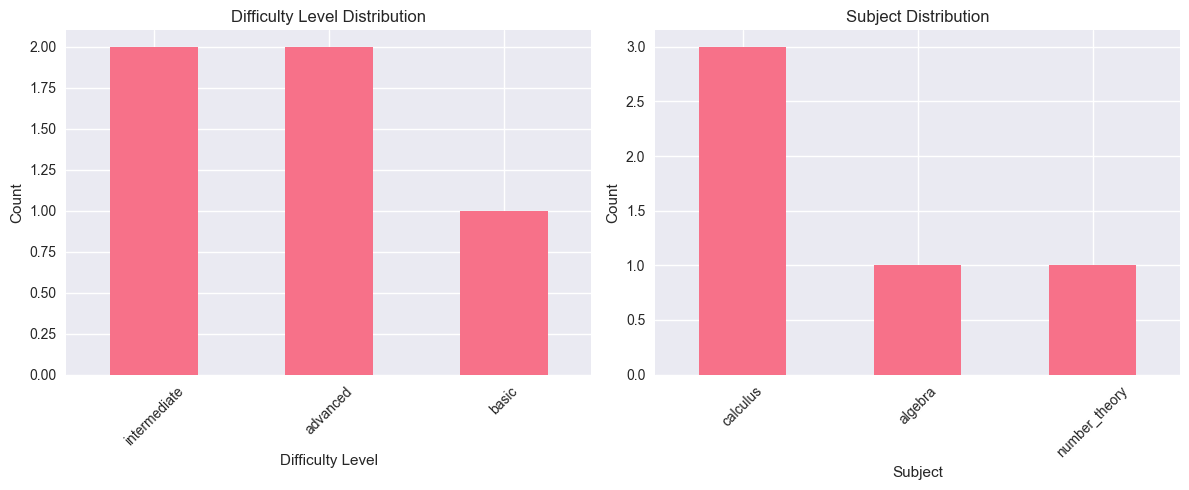

In [16]:
# Analyze difficulty distribution
custom_df = datasets['custom']
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
custom_df['difficulty_level'].value_counts().plot(kind='bar')
plt.title('Difficulty Level Distribution')
plt.xlabel('Difficulty Level')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
custom_df['subject'].value_counts().plot(kind='bar')
plt.title('Subject Distribution')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
